**Figure 6: TCGA somatic epistasis and survival analysis.** **(a)** Single-mutation embedding perturbation: median ratio of max(WT distance) for TCGA somatic pairs vs 1000 Genomes Project population pairs per model. Values >1 indicate cancer mutations are seen as more disruptive; 17/18 models significant (Mann-Whitney U). Track models (terracotta) show the largest separation (Borzoi ratio = 3.07). **(b)** log(Magnitude ratio) distributions for all 18 models comparing TCGA somatic pairs (terracotta) vs 1kGP population pairs (blue), clipped to [−3, 3]. TCGA distributions show wider tails in both corrective (<0) and cumulative (>0) directions, indicating more extreme nonlinear interactions in cancer. White dots indicate medians. **(c–i)** Kaplan-Meier survival curves for four genes with epistasis-specific survival effects. Target group (terracotta): patients carrying both mutations of a specific co-occurring pair. Control group (blue): patients carrying one constituent mutation plus a different second mutation in the same gene, controlling for individual mutation effects and gene-level mutation burden. NF1 splice-site pair shows worse survival across three independent cancer types (endometrial p = 0.003, glioblastoma p = 0.023, bladder p = 2 × 10⁻⁴). WWC3 (Hippo pathway, ensemble rank 7/4,852) shows dramatically worse survival in glioblastoma (p < 0.001). CARD11 (NF-κB signaling, cumulative MR = 1.20) shows better survival in glioblastoma (p = 0.007). PABPC1 (mRNA stability, corrective MR = 0.84, ensemble rank 80/4,852) shows better survival in esophageal (p = 0.009) and lung squamous carcinoma (p = 0.027). Tumor mutation burden verified balanced between groups.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pyarrow.dataset as ds
from scipy.stats import mannwhitneyu, hypergeom

# ── Configuration via paper_data_config ──
sys.path.insert(0, str(Path("..").resolve()))
from paper_data_config import EPISTASIS_PAPER_ROOT

# ParseTCGA — try installed package first, fall back to vendored copy
try:
    from parsetcga import TCGAData
except ImportError:
    sys.path.insert(0, str(Path("../../scripts/data_generation").resolve()))
    from parsetcga import TCGAData

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

tcga = TCGAData()
clin = tcga.clinical.survival_prepared()
surv_patients = set(clin['case_id'])
tmb_series = tcga.mutations.tumor_mutation_burden()

PARQUET_DIR = EPISTASIS_PAPER_ROOT / "combined_parquets" / "new_embeddings"
ANNOT_DIR = EPISTASIS_PAPER_ROOT / "data" / "annotations"
PAIRS_TSV = EPISTASIS_PAPER_ROOT / "data" / "all_pairs_combined.tsv"
OUT_DIR = EPISTASIS_PAPER_ROOT / "figures"

# Style
GRAY_LIGHT, GRAY_MID, GRAY_DARK = "#E8E8E8", "#999999", "#333333"
COL_BLUE, COL_TERRA, COL_NONSIG = "#4A7FB5", "#CB6A49", "#CCCCCC"
mm = 1 / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 7, "axes.linewidth": 0.4, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6.5,
    "xtick.major.size": 2, "ytick.major.size": 2,
    "xtick.major.width": 0.4, "ytick.major.width": 0.4,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.unicode_minus": False,
})

MODELS = {
    "alphagenome": "AlphaGenome", "borzoi": "Borzoi", "caduceus": "Caduceus",
    "convnova": "ConvNova", "dnabert": "DNABERT", "evo2": "Evo2",
    "hyenadna": "HyenaDNA", "mutbert": "MutBERT",
    "nt50_3mer": "NT-50M-3mer", "nt50_multi": "NT-50M",
    "nt100_multi": "NT-100M", "nt250_multi": "NT-250M",
    "nt500_multi": "NT-500M", "nt500_ref": "NT-500M-ref",
    "nt2500_multi": "NT-2.5B", "nt2500_okgp": "NT-2.5B-1kGP",
    "rinalmo": "RiNALMo", "specieslm": "SpeciesLM",
}
TRACK_MODELS = {"alphagenome", "borzoi"}

# Cancer gene sets
census = pd.read_csv(ANNOT_DIR / "census_all_genes.csv")
oncokb = pd.read_csv(ANNOT_DIR / "cancerGeneList.tsv", sep="\t")
cancer_set = (
    set(census[census["Role in Cancer"].str.contains("oncogene|TSG", case=False, na=False)]["Gene Symbol"].str.strip())
    | set(oncokb["Hugo Symbol"])
)

def setup_ax(ax):
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_linewidth(0.4)
        ax.spines[sp].set_color(GRAY_MID)
    ax.tick_params(colors=GRAY_DARK, which="both")

def format_p(p):
    if p >= 0.05: return "n.s."
    if p >= 0.01: return f"p={p:.3f}"
    if p == 0 or p < 1e-300: return "p<1E-300"
    return f"p={p:.1e}".replace("e-0","E-").replace("e-","E-")

def parse_dist(eid):
    parts = eid.split("|")
    return abs(int(parts[1].split(":")[2]) - int(parts[0].split(":")[2]))

def parse_pair(eid):
    m1, m2 = eid.split("|")
    p1, p2 = m1.split(":"), m2.split(":")
    return p1[0], int(p1[2]), int(p2[2])

print("Setup OK")


## Data loading — all 18 models for panels a+b

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Load ALL 18 models for panels a + b
# ═══════════════════════════════════════════════════════════════════════

import os
all_model_keys = sorted([
    f.replace("epistasis_metrics_","").replace("_combined.parquet","")
    for f in os.listdir(PARQUET_DIR) if f.endswith(".parquet") and 'spliceai' not in f
])

model_data = {}
for key in all_model_keys:
    display = MODELS.get(key, key)
    dset = ds.dataset(PARQUET_DIR / f"epistasis_metrics_{key}_combined.parquet")
    avail = [f.name for f in dset.schema]
    cols = [c for c in ['source','epistasis_id','len_WT_M1','len_WT_M2','log_magnitude_ratio'] if c in avail]
    df = dset.to_table(columns=cols,
        filter=ds.field('source').isin(['tcga_doubles','okgp_chr12'])
    ).to_pandas().drop_duplicates(subset=['source','epistasis_id'])
    
    okgp = df[df.source == 'okgp_chr12']
    if len(okgp) > 20000:
        df = pd.concat([df[df.source != 'okgp_chr12'], okgp.sample(20000, random_state=42)])
    model_data[display] = df

print(f"Loaded {len(model_data)} models")

# ── Compute intensity ratios for panel (a) ──
intensity_rows = []
for display, df in model_data.items():
    tcga_d = df[df.source == 'tcga_doubles'].dropna(subset=['len_WT_M1','len_WT_M2'])
    bg_d = df[df.source == 'okgp_chr12'].dropna(subset=['len_WT_M1','len_WT_M2'])
    if len(tcga_d) < 20 or len(bg_d) < 20:
        continue
    tcga_max = np.maximum(tcga_d.len_WT_M1.values, tcga_d.len_WT_M2.values)
    bg_max = np.maximum(bg_d.len_WT_M1.values, bg_d.len_WT_M2.values)
    ratio = np.median(tcga_max) / np.median(bg_max)
    _, p = mannwhitneyu(tcga_max, bg_max, alternative='two-sided')
    key = next((k for k,v in MODELS.items() if v==display), '')
    intensity_rows.append({'model': display, 'ratio': ratio, 'p': p, 'is_track': key in TRACK_MODELS})

int_df = pd.DataFrame(intensity_rows).sort_values('ratio', ascending=True)

# ── Compute log(MR) median shift for sorting panel (b) ──
mr_shift = []
for display, df in model_data.items():
    if 'log_magnitude_ratio' not in df.columns:
        continue
    tv = df.loc[df.source == 'tcga_doubles', 'log_magnitude_ratio'].dropna()
    bv = df.loc[df.source == 'okgp_chr12', 'log_magnitude_ratio'].dropna()
    tv, bv = tv[np.isfinite(tv)], bv[np.isfinite(bv)]
    if len(tv) < 20 or len(bv) < 20:
        continue
    # IQR spread ratio: TCGA IQR / 1kGP IQR (wider = more nonlinear)
    tcga_iqr = np.percentile(tv, 75) - np.percentile(tv, 25)
    bg_iqr = np.percentile(bv, 75) - np.percentile(bv, 25)
    iqr_ratio = tcga_iqr / (bg_iqr + 1e-12)
    key = next((k for k,v in MODELS.items() if v==display), '')
    mr_shift.append({'model': display, 'iqr_ratio': iqr_ratio, 'is_track': key in TRACK_MODELS})

mr_df = pd.DataFrame(mr_shift).sort_values('iqr_ratio', ascending=True)

# ── Build survival cohorts ──
pairs_df = pd.read_csv(PAIRS_TSV, sep='\t', usecols=['source','epistasis_id'], low_memory=False)
tp = pairs_df[pairs_df.source == 'tcga_doubles'].drop_duplicates(subset=['epistasis_id'])

CASES = [
    ("NF1", "TCGA_UCEC", "NF1\nEndometrial"),
    ("NF1", "TCGA_GBM", "NF1\nGlioblastoma"),
    ("NF1", "TCGA_BLCA", "NF1\nBladder"),
    ("WWC3", "TCGA_GBM", "WWC3\nGlioblastoma"),
    ("CARD11", "TCGA_GBM", "CARD11\nGlioblastoma"),
    ("PABPC1", "TCGA_ESCA", "PABPC1\nEsophageal"),
    ("PABPC1", "TCGA_LUSC", "PABPC1\nLung sq."),
]

def build_cohort(gene, project=None):
    gene_tp = tp[tp.epistasis_id.str.startswith(gene + ":")]
    specific = set()
    for eid in gene_tp.epistasis_id:
        _, p1, p2 = parse_pair(eid)
        specific.add((p1, p2))
    epi_positions = set()
    for p1, p2 in specific:
        epi_positions.add(p1); epi_positions.add(p2)
    gm = tcga.mutations.query(genes=[gene])
    if project:
        gm = gm[gm.Proj_name == project]
    pp = gm.groupby('case_id').agg(positions=('Start_Position', lambda x: set(x)))
    multi = pp[pp.positions.apply(len) >= 2]
    target_ids, control_ids = set(), set()
    for patient, row in multi.iterrows():
        pos = row.positions
        if any(p1 in pos and p2 in pos for p1, p2 in specific):
            target_ids.add(patient)
        elif bool(pos & epi_positions) and len(pos - epi_positions) >= 1:
            control_ids.add(patient)
    control_ids -= target_ids
    return target_ids & surv_patients, control_ids & surv_patients

cohorts = {}
surv_results = []
for gene, project, label in CASES:
    t_ids, c_ids = build_cohort(gene, project)
    if len(t_ids) < 3 or len(c_ids) < 3:
        continue
    cohorts[label] = (t_ids, c_ids)
    tc = clin[clin.case_id.isin(t_ids)]
    cc = clin[clin.case_id.isin(c_ids)]
    lr = logrank_test(tc['duration'], cc['duration'], tc['event'], cc['event'])
    surv_results.append({'label': label, 'p': lr.p_value})

print(f"{len(cohorts)} survival panels ready")

Loaded 18 models
7 survival panels ready


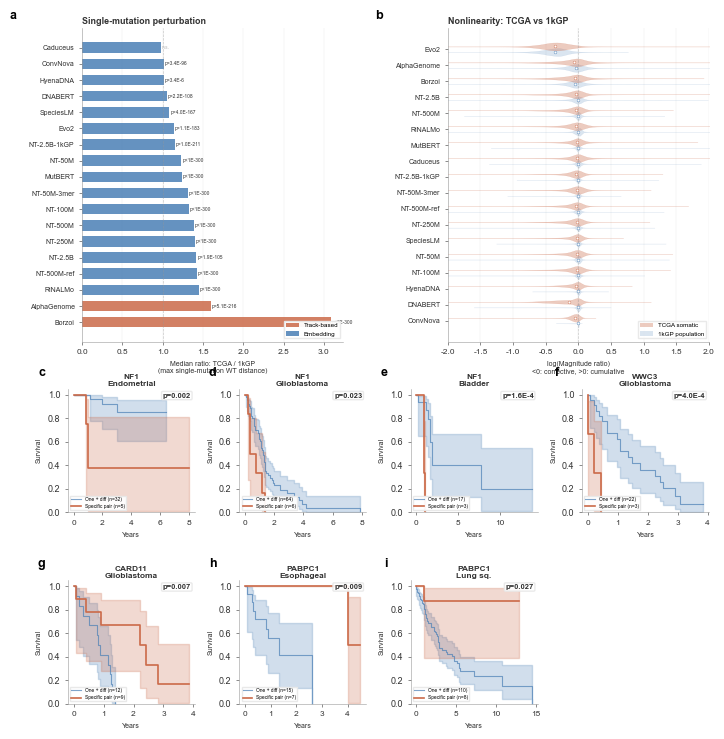

Saved fig_tcga_combined to /Users/nicolaslynn/Downloads/output_figs


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Combined figure — 2 top panels (all 18 models) + survival below
# (a) Single-mutation perturbation ratio
# (b) log(MR) grouped violins — TCGA vs 1kGP, all 18 models
# (c–i) Survival KM panels
# ═══════════════════════════════════════════════════════════════════════

n_models = len(int_df)
n_surv = len(cohorts)
surv_cols = 4
surv_rows = int(np.ceil(n_surv / surv_cols))

top_h = max(85, 4.2 * n_models + 10)
bot_h = 42 * surv_rows
total_h = top_h + bot_h + 12

fig = plt.figure(figsize=(183 * mm, total_h * mm))

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.97,
                           top=1 - 6/total_h, bottom=1 - top_h/total_h,
                           wspace=0.40)
gs_bot = fig.add_gridspec(surv_rows, surv_cols, left=0.08, right=0.97,
                           top=1 - (top_h + 12)/total_h, bottom=4/total_h,
                           hspace=0.55, wspace=0.35)

# Sort models consistently for both panels
model_order_a = int_df.model.tolist()  # sorted by ratio ascending

# ═══════════════════════════════════════════════════════════════
# Panel (a): Single-mutation perturbation ratio — all 18 models
# ═══════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs_top[0])
setup_ax(ax_a)

y_a = np.arange(len(int_df))
colors_a = [COL_TERRA if r.is_track else COL_BLUE for _, r in int_df.iterrows()]

ax_a.barh(y_a, int_df.ratio.values, height=0.65, color=colors_a, edgecolor="none", alpha=0.85)
ax_a.axvline(1.0, color=GRAY_MID, linewidth=0.5, linestyle="--", alpha=0.5)

for i in range(len(int_df)):
    p = int_df.iloc[i]['p']
    r = int_df.iloc[i]['ratio']
    p_str = format_p(p)
    col = GRAY_DARK if p < 0.05 else "#BBBBBB"
    ax_a.text(r + 0.01, y_a[i], p_str, ha="left", va="center", fontsize=3.5, color=col)

ax_a.set_yticks(y_a)
ax_a.set_yticklabels(int_df.model.tolist(), fontsize=5)
ax_a.invert_yaxis()
ax_a.set_xlabel("Median ratio: TCGA / 1kGP\n(max single-mutation WT distance)", fontsize=5, color=GRAY_DARK)
ax_a.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_a.set_axisbelow(True)
ax_a.set_title("Single-mutation perturbation", fontsize=6.5, color=GRAY_DARK, pad=3, fontweight="bold", loc="left")

track_p = mpatches.Patch(facecolor=COL_TERRA, alpha=0.85, label="Track-based")
embed_p = mpatches.Patch(facecolor=COL_BLUE, alpha=0.85, label="Embedding")
ax_a.legend(handles=[track_p, embed_p], fontsize=4.5, loc="lower right",
            frameon=True, fancybox=False, edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.3)
ax_a.text(-0.25, 1.02, "a", transform=ax_a.transAxes, fontsize=9, fontweight="bold", va="bottom", ha="right")

# ═══════════════════════════════════════════════════════════════
# Panel (b): log(MR) grouped violins — all 18 models
# ═══════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs_top[1])
setup_ax(ax_b)

# Sort by IQR ratio (same order as mr_df)
viol_order = mr_df.model.tolist()
n_v = len(viol_order)
y_v = np.arange(n_v)
vw = 0.35

tcga_viol, bg_viol = [], []
for m in viol_order:
    df = model_data[m]
    tv = df.loc[df.source == 'tcga_doubles', 'log_magnitude_ratio'].dropna().values
    bv = df.loc[df.source == 'okgp_chr12', 'log_magnitude_ratio'].dropna().values
    tv, bv = tv[np.isfinite(tv)], bv[np.isfinite(bv)]
    tv = np.clip(tv, -3, 3)
    bv = np.clip(bv, -3, 3)
    tcga_viol.append(tv if len(tv) >= 2 else np.array([0.0, 0.0]))
    bg_viol.append(bv if len(bv) >= 2 else np.array([0.0, 0.0]))

parts_bg = ax_b.violinplot(bg_viol, positions=y_v + vw/2, widths=0.5,
    showmeans=False, showmedians=False, showextrema=False, vert=False)
for pc in parts_bg["bodies"]:
    pc.set_facecolor(COL_BLUE); pc.set_alpha(0.2); pc.set_edgecolor(COL_BLUE); pc.set_linewidth(0.2)

parts_tc = ax_b.violinplot(tcga_viol, positions=y_v - vw/2, widths=0.5,
    showmeans=False, showmedians=False, showextrema=False, vert=False)
for pc in parts_tc["bodies"]:
    pc.set_facecolor(COL_TERRA); pc.set_alpha(0.35); pc.set_edgecolor(COL_TERRA); pc.set_linewidth(0.2)

# Median dots only (no IQR bars — cleaner)
for i in range(n_v):
    for data, y_off, col in [(bg_viol[i], vw/2, COL_BLUE), (tcga_viol[i], -vw/2, COL_TERRA)]:
        q50 = np.median(data)
        ax_b.scatter([q50], [y_v[i] + y_off], color="white", s=4, zorder=4, edgecolors=col, linewidths=0.3)

ax_b.axvline(0, color=GRAY_MID, linewidth=0.5, linestyle="--", alpha=0.5)
ax_b.set_yticks(y_v)
ax_b.set_yticklabels(viol_order, fontsize=5)
ax_b.invert_yaxis()
ax_b.set_xlim(-2.0, 2.0)
ax_b.set_xlabel("log(Magnitude ratio)\n<0: corrective, >0: cumulative", fontsize=5, color=GRAY_DARK)
ax_b.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_b.set_axisbelow(True)

ax_b.legend(handles=[
    mpatches.Patch(facecolor=COL_TERRA, alpha=0.35, label="TCGA somatic"),
    mpatches.Patch(facecolor=COL_BLUE, alpha=0.2, label="1kGP population"),
], fontsize=4.5, loc="lower right", frameon=True, fancybox=False,
   edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.3)

ax_b.set_title("Nonlinearity: TCGA vs 1kGP", fontsize=6.5, color=GRAY_DARK, pad=3, fontweight="bold", loc="left")
ax_b.text(-0.25, 1.02, "b", transform=ax_b.transAxes, fontsize=9, fontweight="bold", va="bottom", ha="right")

# ═══════════════════════════════════════════════════════════════
# Bottom panels: Survival KM curves
# ═══════════════════════════════════════════════════════════════
letters = "cdefghi"

for idx, sr in enumerate(surv_results):
    ax = fig.add_subplot(gs_bot[idx // surv_cols, idx % surv_cols])
    setup_ax(ax)
    
    label = sr['label']
    if label not in cohorts:
        ax.set_visible(False)
        continue
    
    t_ids, c_ids = cohorts[label]
    tc = clin[clin.case_id.isin(t_ids)]
    cc = clin[clin.case_id.isin(c_ids)]
    
    kmf_t = KaplanMeierFitter()
    kmf_c = KaplanMeierFitter()
    kmf_t.fit(tc.duration, tc.event, label=f"Specific pair (n={len(tc)})")
    kmf_c.fit(cc.duration, cc.event, label=f"One + diff (n={len(cc)})")
    
    kmf_c.plot_survival_function(ax=ax, color=COL_BLUE, linewidth=0.8, alpha=0.7)
    kmf_t.plot_survival_function(ax=ax, color=COL_TERRA, linewidth=1.2)
    
    p = sr['p']
    p_str = f"p={p:.3f}" if p >= 0.001 else f"p={p:.1e}".replace("e-0","E-").replace("e-","E-")
    ax.text(0.97, 0.97, p_str, transform=ax.transAxes, fontsize=5.5,
            ha="right", va="top", color=GRAY_DARK, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=GRAY_LIGHT, alpha=0.9))
    
    ax.set_title(label, fontsize=6, fontweight="bold", color=GRAY_DARK, pad=2)
    ax.set_xlabel("Years", fontsize=5, color=GRAY_DARK)
    ax.set_ylabel("Survival", fontsize=5, color=GRAY_DARK)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=3.5, loc="lower left", frameon=True, fancybox=False,
              edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.2)
    ax.text(-0.18, 1.08, letters[idx], transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right")

# Hide empty
for idx in range(n_surv, surv_rows * surv_cols):
    ax = fig.add_subplot(gs_bot[idx // surv_cols, idx % surv_cols])
    ax.set_visible(False)

for ext in (".png", ".pdf"):
    fig.savefig(OUT_DIR / f"fig_tcga_combined{ext}", dpi=600,
                bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_tcga_combined to {OUT_DIR}")

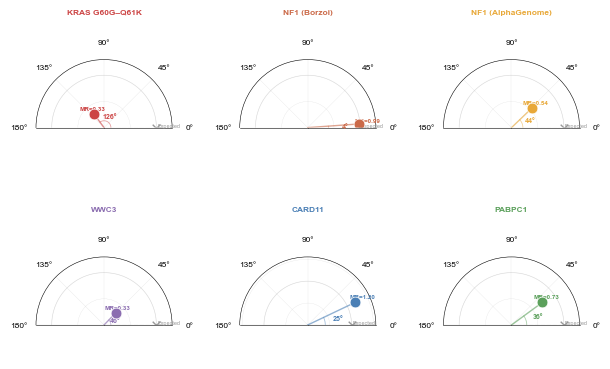

Saved fig_epistasis_polar to /Users/nicolaslynn/Downloads/output_figs

Label                          MR  cos(o,e)   Angle
----------------------------------------------------
  KRAS G60G–Q61K              0.327    -0.593   126.4°
  NF1 (Borzoi)                0.986     0.997     4.1°
  NF1 (AlphaGenome)           0.544     0.724    43.6°
  WWC3                        0.326     0.693    46.1°
  CARD11                      1.195     0.903    25.5°
  PABPC1                      0.728     0.807    36.2°


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# Epistasis geometry: polar diagrams per case study
# WT at origin, Expected at (1, 0), Observed at (MR, arccos(cos_obs_exp))
# ═══════════════════════════════════════════════════════════════════════

import pyarrow.dataset as ds

CASE_PAIRS = {
    "KRAS G60G–Q61K":  ("kras_neighborhood", "KRAS:12:25227343:G:T:N|KRAS:12:25227344:A:T:N"),
    "NF1 (Borzoi)":    ("tcga_doubles", "NF1:17:31181787:TA:-:P|NF1:17:31181789:A:G:P"),
    "NF1 (AlphaGenome)": ("tcga_doubles", "NF1:17:31181787:TA:-:P|NF1:17:31181789:A:G:P"),
    "WWC3":            ("tcga_doubles", "WWC3:X:10129989:T:G:P|WWC3:X:10129990:A:G:P"),
    "CARD11":          ("tcga_doubles", "CARD11:7:2915204:A:G:N|CARD11:7:2915206:T:G:N"),
    "PABPC1":          ("tcga_doubles", "PABPC1:8:100706737:G:A:N|PABPC1:8:100706740:C:T:N"),
}

# Which model to use per case
CASE_MODELS = {
    "KRAS G60G–Q61K": "borzoi",
    "NF1 (Borzoi)": "borzoi",
    "NF1 (AlphaGenome)": "alphagenome",
    "WWC3": "borzoi",
    "CARD11": "borzoi",
    "PABPC1": "borzoi",
}

case_results = {}
for label, (source, eid) in CASE_PAIRS.items():
    model_key = CASE_MODELS[label]
    dset = ds.dataset(PARQUET_DIR / f"epistasis_metrics_{model_key}_combined.parquet")
    df = dset.to_table(
        columns=['source','epistasis_id','magnitude_ratio','cos_obs_exp'],
        filter=ds.field('source') == source
    ).to_pandas()
    df = df[df.epistasis_id == eid].drop_duplicates(subset=['epistasis_id'])
    if len(df) > 0:
        r = df.iloc[0]
        case_results[label] = (r.magnitude_ratio, r.cos_obs_exp)

case_colors = {
    "KRAS G60G–Q61K": "#CC4444",
    "NF1 (Borzoi)": COL_TERRA,
    "NF1 (AlphaGenome)": "#E8A838",
    "WWC3": "#8B6DB0",
    "CARD11": COL_BLUE,
    "PABPC1": "#5BA05B",
}

# ── One subplot per case ──
labels = list(case_results.keys())
n_cases = len(labels)
ncols = 3
nrows = int(np.ceil(n_cases / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(183 * mm, 55 * nrows * mm),
                          subplot_kw={'projection': 'polar'},
                          gridspec_kw={"hspace": 0.45, "wspace": 0.35})
axes = axes.flatten()

for idx, label in enumerate(labels):
    ax = axes[idx]
    mr, cos_oe = case_results[label]
    phi = np.arccos(np.clip(cos_oe, -1, 1))  # angle from expected direction
    col = case_colors[label]
    
    # WT at origin (implicit)
    # Expected at (r=1, theta=0)
    ax.scatter([0], [1], color=GRAY_MID, marker='x', s=30, zorder=4, linewidths=1)
    ax.annotate("Expected", (0, 1), fontsize=4, color=GRAY_MID,
                xytext=(0.15, 0.08), textcoords="offset fontsize", ha="left")
    
    # Observed at (r=MR, theta=phi)
    ax.scatter([phi], [mr], color=col, s=60, zorder=5,
               edgecolors="white", linewidths=0.5)
    
    # Line from origin to observed
    ax.plot([0, phi], [0, mr], color=col, linewidth=1.0, alpha=0.6, zorder=3)
    # Line from origin to expected
    ax.plot([0, 0], [0, 1], color=GRAY_MID, linewidth=0.8, alpha=0.4, linestyle="--", zorder=2)
    
    # Arc showing angle
    arc_r = min(mr, 1) * 0.4
    arc_theta = np.linspace(0, phi, 30)
    ax.plot(arc_theta, [arc_r] * 30, color=col, linewidth=0.6, alpha=0.5)
    
    # MR = 1 circle (additive magnitude)
    circle_theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(circle_theta, [1] * 100, color=GRAY_LIGHT, linewidth=0.5, linestyle="-", zorder=1)
    
    # Annotate MR and angle
    ax.text(phi * 0.5, arc_r * 1.8, f"{np.degrees(phi):.0f}°", fontsize=5,
            color=col, ha="center", va="center", fontweight="bold")
    
    mr_label = f"MR={mr:.2f}" if mr >= 0.01 else f"MR={mr:.3f}"
    ax.text(phi, mr * 1.15, mr_label, fontsize=4.5, color=col,
            ha="center", va="bottom", fontweight="bold")
    
    # Style
    rmax = max(1.3, mr * 1.3)
    ax.set_rmax(rmax)
    ax.set_rticks([0.5, 1.0] + ([1.5] if rmax > 1.3 else []))
    ax.set_yticklabels([])
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_theta_zero_location("E")
    ax.grid(True, linewidth=0.2, alpha=0.4)
    ax.set_title(label, fontsize=6, fontweight="bold", color=col, pad=8)

# Hide empty axes
for idx in range(n_cases, len(axes)):
    axes[idx].set_visible(False)

for ext in (".png", ".pdf"):
    fig.savefig(OUT_DIR / f"fig_epistasis_polar{ext}", dpi=600,
                bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()

print(f"Saved fig_epistasis_polar to {OUT_DIR}")
print(f"\n{'Label':25s} {'MR':>7s} {'cos(o,e)':>9s} {'Angle':>7s}")
print("-" * 52)
for label, (mr, cos_oe) in case_results.items():
    angle = np.degrees(np.arccos(np.clip(cos_oe, -1, 1)))
    print(f"  {label:25s} {mr:7.3f} {cos_oe:9.3f} {angle:7.1f}°")